<a href="https://colab.research.google.com/github/sabbirpuspo/LearningforMe/blob/main/Superstore_Sales_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install boosting libraries
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Ensemble models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 20   # same seed everywhere -> reproducible results

In [4]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/SkillMorph Datasets/samplesuperstore.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [5]:
# Column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [6]:
# Summary statistics of numeric columns
df.describe().round(2)

,Row ID,Sales,Quantity,Discount,Profit
count,10194.00,10194.00,10194.00,10194.00,10194.00
mean,5097.50,228.23,3.79,0.16,28.67
std,2942.90,619.91,2.23,0.21,232.47
min,1.00,0.44,1.00,0.00,-6599.98
25%,2549.25,17.22,2.00,0.00,1.76
50%,5097.50,53.91,3.00,0.20,8.69
75%,7645.75,209.50,5.00,0.20,29.30
max,10194.00,22638.48,14.00,0.80,8399.98


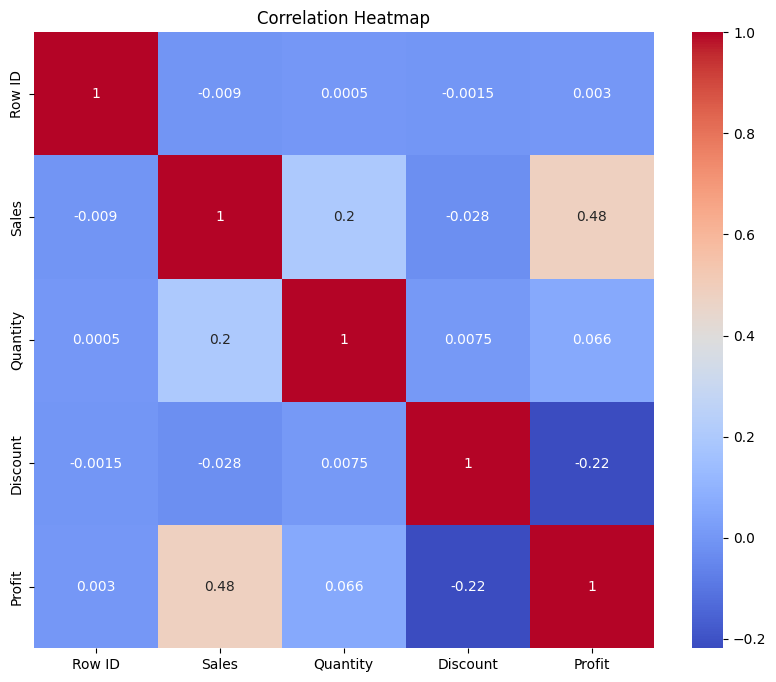

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
# TODO: Create profit_class (0 = Loss, 1 = Low margin, 2 = High margin)
TARGET = "profit_class"
class_names = ["Loss", "Low margin", "High margin"]

# Only create profit_class if 'Profit' column is available and 'profit_class' isn't already created
if "Profit" in df.columns and TARGET not in df.columns:
    margin = df["Profit"] / df["Sales"]
    df[TARGET] = np.select([df["Profit"] < 0, margin < 0.25], [0, 1], default=2)
elif "Profit" not in df.columns and TARGET not in df.columns:
    # If 'Profit' is missing and TARGET column isn't created, raise an error as we cannot proceed as intended.
    raise ValueError("Cannot create 'profit_class': 'Profit' column is missing and 'profit_class' is not present in df.")

features = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category",
            "Sales", "Quantity", "Discount"]

# Ensure TARGET is included in the final set of columns if it's meant to be kept
if TARGET not in features:
    features.append(TARGET)

# Filter df to keep only the selected features + target, and drop duplicates
# This implicitly drops 'Profit' if it was present and not in `features`.
df = df[features].drop_duplicates()
df.head()
# TODO: Keep the selected features + target (Handled)
# TODO: Drop Profit (Handled)

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,profit_class
0,Standard Class,Consumer,Central,Office Supplies,Paper,16.448,2,0.2,2
1,Standard Class,Home Office,Central,Office Supplies,Binders,3.540,2,0.8,0
2,Standard Class,Home Office,Central,Office Supplies,Labels,11.784,3,0.2,2
3,Standard Class,Home Office,Central,Office Supplies,Storage,272.736,3,0.2,0
4,Standard Class,Consumer,East,Office Supplies,Art,19.536,3,0.2,2


In [13]:
# Features (X) and target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Convert text columns to numbers
for col in X.select_dtypes(exclude="number").columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X.head()

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount
0,3,0,0,1,12,16.448,2,0.2
1,3,2,0,1,3,3.540,2,0.8
2,3,2,0,1,10,11.784,3,0.2
3,3,2,0,1,14,272.736,3,0.2
4,3,0,1,1,2,19.536,3,0.2


In [14]:
# Stratified 80/20 split keeps class proportions equal in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples: 7805
Testing samples : 1952


In [15]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)   # probabilities -> needed for ROC/AUC

print(f"Random Forest | accuracy = {accuracy_score(y_test, rf_pred):.4f}")

Random Forest | accuracy = 0.8412


In [16]:
# Extra Trees
et_model = ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
et_model.fit(X_train, y_train)

et_pred  = et_model.predict(X_test)
et_proba = et_model.predict_proba(X_test)

print(f"Extra Trees | accuracy = {accuracy_score(y_test, et_pred):.4f}")

Extra Trees | accuracy = 0.8202


In [17]:
# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                              random_state=RANDOM_STATE)
xgb_model.fit(X_train, y_train)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

print(f"XGBoost | accuracy = {accuracy_score(y_test, xgb_pred):.4f}")

XGBoost | accuracy = 0.8571


In [18]:

# LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                               random_state=RANDOM_STATE, verbose=-1)
lgb_model.fit(X_train, y_train)

lgb_pred  = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)

print(f"LightGBM | accuracy = {accuracy_score(y_test, lgb_pred):.4f}")

LightGBM | accuracy = 0.8658


In [19]:
# CatBoost
cat_model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=5,
                               random_state=RANDOM_STATE, verbose=0)
cat_model.fit(X_train, y_train)

cat_pred  = cat_model.predict(X_test).ravel().astype(int)   # flatten to 1-D labels
cat_proba = cat_model.predict_proba(X_test)

print(f"CatBoost | accuracy = {accuracy_score(y_test, cat_pred):.4f}")


CatBoost | accuracy = 0.8509


In [20]:
# Stacking: 5 base models + Logistic Regression as the meta-model
stack_model = StackingClassifier(
    estimators=[("rf", rf_model), ("et", et_model), ("xgb", xgb_model),
                ("lgb", lgb_model), ("cat", cat_model)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
)
stack_model.fit(X_train, y_train)

stack_pred  = stack_model.predict(X_test)
stack_proba = stack_model.predict_proba(X_test)

print(f"Stacking | accuracy = {accuracy_score(y_test, stack_pred):.4f}")

Stacking | accuracy = 0.8555


In [29]:

models = {
    "Random Forest": (rf_pred, rf_proba),
    "Extra Trees":   (et_pred, et_proba),
    "XGBoost":       (xgb_pred, xgb_proba),
    "LightGBM":      (lgb_pred, lgb_proba),
    "CatBoost":      (cat_pred, cat_proba),
    "Stacking":      (stack_pred, stack_proba),
}

rows = []
for name, (pred, proba) in models.items():
    rows.append({
        "Model":                name,
        "Accuracy":             accuracy_score(y_test, pred),
        "Precision (macro)":    precision_score(y_test, pred, average="macro"),
        "Recall (macro)":       recall_score(y_test, pred, average="macro"),
        "F1 (macro)":           f1_score(y_test, pred, average="macro"),
        "Precision (weighted)": precision_score(y_test, pred, average="weighted"),
        "Recall (weighted)":    recall_score(y_test, pred, average="weighted"),
        "F1 (weighted)":        f1_score(y_test, pred, average="weighted"),
        "ROC-AUC":              roc_auc_score(y_test, proba, multi_class='ovr', average='weighted'),
    })

results = pd.DataFrame(rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
best_model = results.iloc[0]["Model"]
results.round(4)


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),ROC-AUC
0,LightGBM,0.8658,0.8450,0.8391,0.8419,0.8658,0.8658,0.8657,0.9685
1,XGBoost,0.8571,0.8373,0.8264,0.8315,0.8571,0.8571,0.8569,0.9677
2,Stacking,0.8555,0.8399,0.8217,0.8299,0.8567,0.8555,0.8555,0.9665
3,CatBoost,0.8509,0.8382,0.8146,0.8247,0.8537,0.8509,0.8512,0.9654
4,Random Forest,0.8412,0.8223,0.8108,0.8162,0.8414,0.8412,0.8411,0.9561
5,Extra Trees,0.8202,0.7969,0.7870,0.7917,0.8196,0.8202,0.8197,0.9380


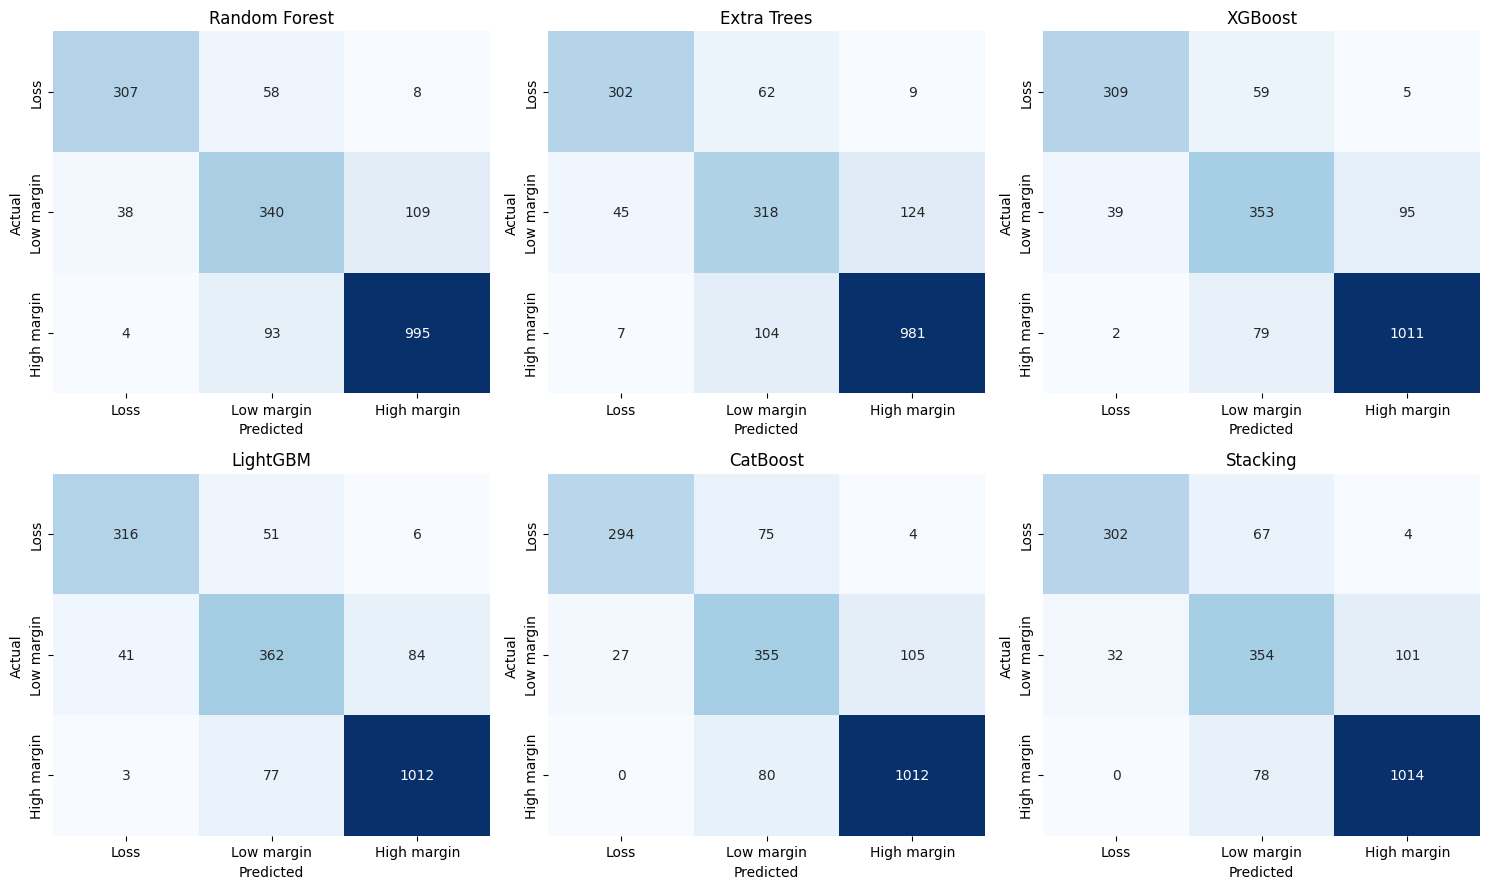

In [30]:
# Confusion matrix for every model
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, (pred, proba)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

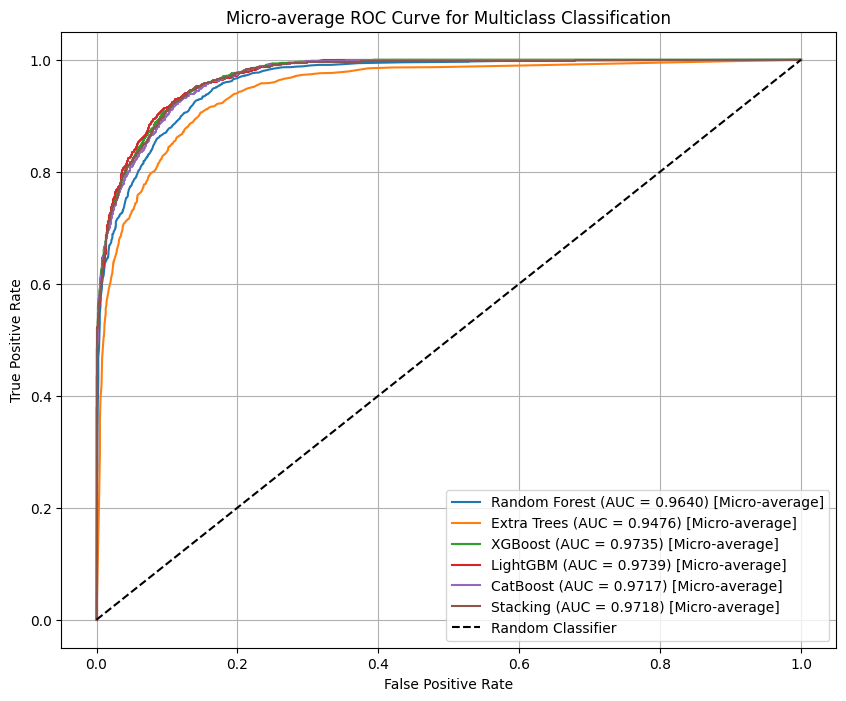

In [32]:
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

plt.figure(figsize=(10, 8))

for name, (pred, proba) in models.items():
    # Calculate micro-average ROC curve
    # Flatten the true binary labels and probabilities for all classes
    fpr_micro, tpr_micro, _ = roc_curve(y_test_binarized.ravel(), proba.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, label=f"{name} (AUC = {auc_micro:.4f}) [Micro-average]")

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-average ROC Curve for Multiclass Classification")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()